# Customer Churn — Modelado Predictivo

**Notebook 02 · Fases 8 a 16 del proyecto**

> *Material académico.* Igual que el notebook 01, cada sección explica **qué** se
> hace y **por qué**, para leerse como un tutorial de un flujo de Machine Learning
> real, no solo como código ejecutable.

## Contenido

| Fase | Sección |
|------|---------|
| 8  | Selección de variables (VIF + información mutua) |
| 9  | División train / test estratificada |
| 10 | Preprocesamiento con `Pipeline` + `ColumnTransformer` |
| 11 | Modelos baseline (trivial, LR, RF, XGBoost) |
| 12 | Validación cruzada estratificada |
| 13 | Ajuste de hiperparámetros (`RandomizedSearchCV`) |
| 14 | Evaluación en el set de test |
| 15 | Análisis de errores e importancia de variables (SHAP) |
| 16 | Interpretación de negocio y respuesta a las hipótesis |

### Punto de partida (heredado del notebook 01)
- Dataset limpio en `data/processed/churn_clean.csv` (7,043 × 22, 0 NaN).
- Target `churn` ∈ {0,1}, ~26.5 % positivos → **clases desbalanceadas**.
- `gender` y `phone_service` **sin** asociación con churn → se descartan.
- Multicolinealidad `tenure` ↔ `total_charges` (r ≈ 0.83) → se gestiona aquí.
- Ninguna numérica es normal → ya validado con métodos no paramétricos.

### Métrica principal
Usamos el **F1 de la clase positiva (churn = 1)** como métrica de decisión. Con
desbalance, el *accuracy* premia "predecir siempre que se queda"; F1 equilibra
**precision** (no molestar a clientes fieles) y **recall** (no perder churners).


In [1]:
# Imports y configuración inicial
import sys
sys.path.insert(0, '..')          # para importar el paquete `src`

import warnings
warnings.filterwarnings('ignore')  # silencia avisos de convergencia/versión (didáctico)

import json, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate,
)

# Toda la "fontanería" reutilizable vive en src/modeling.py (funciones puras).
from src import modeling as M

RANDOM_STATE = M.RANDOM_STATE      # 42, semilla global
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda v: f'{v:0.4f}')

df = pd.read_csv('../data/processed/churn_clean.csv')
print(f'Dataset limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Tasa global de churn: {df["churn"].mean():.4f}')
df.head(3)


Dataset limpio: 7,043 filas × 22 columnas
Tasa global de churn: 0.2654


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,tenure_group
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.8500,0,0-12m
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.9500,1889.5000,0,25-48m
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.1500,1,0-12m


---
## Fase 8 — Selección de variables

Objetivo: quedarnos con un conjunto de predictoras **informativas y no
redundantes**. Tres decisiones:

1. **Descartar `gender` y `phone_service`.** El chi² del notebook 01 mostró que
   no se asocian con churn (p > 0.05, Cramér's V ≈ 0). Mantenerlas solo añade
   ruido y dimensionalidad.
2. **Diagnosticar multicolinealidad con VIF.** `tenure` y `total_charges` están
   muy correlacionadas; el VIF nos dice si una es redundante.
3. **Rankear relevancia con información mutua (MI)**, como segunda opinión
   independiente del Cramér's V.


In [2]:
# Construimos la lista de features candidatas:
# fuera el id, el target, la variable derivada tenure_group (colineal con tenure)
# y las dos descartadas por el EDA.
drop_cols = M.DROPPED_FEATURES + M.ID_COLS + [M.TARGET, 'tenure_group']
features = [c for c in df.columns if c not in drop_cols]

numeric_cols, categorical_cols = M.split_feature_types(df, features)
print('Descartadas por chi² no significativo:', M.DROPPED_FEATURES)
print(f'\nNuméricas ({len(numeric_cols)}): {numeric_cols}')
print(f'Categóricas ({len(categorical_cols)}): {categorical_cols}')


Descartadas por chi² no significativo: ['gender', 'phone_service']

Numéricas (3): ['tenure', 'monthly_charges', 'total_charges']
Categóricas (14): ['senior_citizen', 'partner', 'dependents', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


In [3]:
# --- VIF (Variance Inflation Factor) sobre las numéricas ---
# Regla de lectura: VIF<5 ok, 5-10 moderado, >10 multicolinealidad severa.
vif = M.compute_vif(df, numeric_cols)
vif


,variable,VIF
0,total_charges,9.5109
1,tenure,5.8367
2,monthly_charges,3.2167


**Lectura del VIF.** `total_charges` (≈ 9.5) y `tenure` (≈ 5.8) muestran
colinealidad alta pero **por debajo del umbral severo de 10**. Es esperable:
`total_charges ≈ tenure × monthly_charges`.

**Decisión: conservar las tres numéricas.** Justificación:
- Los modelos basados en árboles (**Random Forest, XGBoost**) son *invariantes*
  a la multicolinealidad: no afecta sus particiones.
- La **Logistic Regression** la neutraliza con **regularización L1/L2** (la
  probamos en el tuning de la Fase 13).
- Eliminar `total_charges` descartaría información de "valor acumulado del
  cliente". Como ningún modelo se ve perjudicado, preferimos conservarla.

Esta es la alternativa más simple e interpretable; la opción de eliminarla se
documenta pero se descarta.


In [4]:
# --- Información mutua: relevancia de cada feature frente a churn ---
# Capta dependencias de cualquier forma (no solo lineales/monótonas).
mi = M.mutual_information_ranking(df, features)
mi.head(15)


,variable,mutual_info
0,contract,0.0985
1,tenure,0.0673
2,online_security,0.0647
3,tech_support,0.0630
4,internet_service,0.0556
5,online_backup,0.0468
6,total_charges,0.0448
7,payment_method,0.0445
8,device_protection,0.0439
9,monthly_charges,0.0398


La MI confirma el ranking del EDA: **`contract`, `tenure`,
`online_security`, `tech_support`, `internet_service`** encabezan la lista —
exactamente las variables señaladas por Cramér's V. Dos rankings independientes
(MI y Cramér's V) coincidiendo nos da confianza en el conjunto de features.

**Conjunto final:** 3 numéricas + 14 categóricas = **17 predictoras**.


---
## Fase 9 — División train / test

80 % entrenamiento, 20 % prueba. Usamos `stratify=y` para que **ambos conjuntos
conserven la proporción de churn** (~26.5 %): con clases desbalanceadas, un split
aleatorio simple podría dejar el test con muy pocos positivos y distorsionar las
métricas. Fijamos `random_state=42` para reproducibilidad.


In [5]:
X = df[features]
y = df[M.TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)

print(f'Train: {X_train.shape[0]:,} filas | churn = {y_train.mean():.4f}')
print(f'Test:  {X_test.shape[0]:,} filas | churn = {y_test.mean():.4f}')
print('\nLa estratificación mantiene idéntica la tasa de churn en ambos splits.')


Train: 5,634 filas | churn = 0.2654
Test:  1,409 filas | churn = 0.2654

La estratificación mantiene idéntica la tasa de churn en ambos splits.


---
## Fase 10 — Preprocesamiento (`Pipeline` + `ColumnTransformer`)

**No transformamos a mano.** Encapsulamos el preprocesamiento en un
`ColumnTransformer` dentro de un `Pipeline`. Ventajas:

- **Sin *data leakage*:** el `StandardScaler` se ajusta solo con el train de
  cada fold durante la validación cruzada, nunca con el test.
- **Artefacto único serializable:** el mismo objeto que entrena es el que el
  dashboard cargará con `joblib` y aplicará sobre datos crudos.

Transformaciones:
- **Numéricas → `StandardScaler`** (clave para LR; inocuo para árboles).
- **Categóricas → `OneHotEncoder(drop='first', handle_unknown='ignore')`**
  (`drop='first'` evita colinealidad de dummies; `handle_unknown='ignore'`
  protege al dashboard ante categorías no vistas).


In [6]:
preprocessor = M.build_preprocessor(numeric_cols, categorical_cols)

# Ajuste de demostración para ver cuántas columnas genera el one-hot encoding.
preprocessor.fit(X_train)
feature_names_out = M.get_feature_names(M.build_pipeline(preprocessor, M.LogisticRegression()))
print(f'Tras el preprocesamiento: {len(feature_names_out)} columnas '
      f'(3 numéricas + {len(feature_names_out)-3} dummies).')
print('\nEjemplos de nombres generados:')
print(feature_names_out[:8], '...')


Tras el preprocesamiento: 28 columnas (3 numéricas + 25 dummies).

Ejemplos de nombres generados:
['num__tenure', 'num__monthly_charges', 'num__total_charges', 'cat__senior_citizen_Yes', 'cat__partner_Yes', 'cat__dependents_Yes', 'cat__multiple_lines_No phone service', 'cat__multiple_lines_Yes'] ...


---
## Fase 11 — Modelos baseline (parámetros por defecto)

Entrenamos cuatro modelos con configuración por defecto para tener un punto de
comparación honesto:

- **Dummy (clase mayoritaria):** piso mínimo. Predice siempre "no churn".
  Cualquier modelo útil debe superarlo de forma clara.
- **Logistic Regression:** baseline lineal, interpretable.
- **Random Forest:** ensemble robusto, captura no linealidades e interacciones.
- **XGBoost:** *gradient boosting*, estado del arte en datos tabulares.

Reportamos accuracy, precision, recall, F1 y AUC en **train y test**.


In [7]:
base_models = M.get_base_models(y_train)
base_results, fitted_base = {}, {}

for name, mdl in base_models.items():
    pipe = M.build_pipeline(M.build_preprocessor(numeric_cols, categorical_cols), mdl)
    base_results[name] = M.evaluate_model(pipe, X_train, y_train, X_test, y_test)
    fitted_base[name] = pipe

print('=== Métricas en TEST (parámetros por defecto) ===')
M.metrics_dataframe(base_results, 'test')


=== Métricas en TEST (parámetros por defecto) ===


,accuracy,precision,recall,f1,roc_auc,pr_auc
Dummy,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654
LogisticRegression,0.8048,0.6552,0.5588,0.6032,0.8427,0.6358
RandomForest,0.7935,0.6407,0.5053,0.5650,0.8244,0.6226
XGBoost,0.7530,0.5275,0.6658,0.5887,0.8167,0.6121


In [8]:
# Comparación train vs test para detectar overfitting temprano.
print('=== Métricas en TRAIN ===')
M.metrics_dataframe(base_results, 'train')


=== Métricas en TRAIN ===


,accuracy,precision,recall,f1,roc_auc,pr_auc
Dummy,0.7346,0.0000,0.0000,0.0000,0.5000,0.2654
LogisticRegression,0.8051,0.6584,0.5518,0.6004,0.8492,0.6672
RandomForest,0.9977,0.9966,0.9946,0.9956,0.9998,0.9994
XGBoost,0.9217,0.7762,0.9906,0.8704,0.9858,0.9558


**Lectura de los baselines.**
- El **Dummy** logra ~73 % de accuracy pero **F1 = 0** (no detecta ni un
  churner): demuestra por qué el accuracy engaña con desbalance.
- **Random Forest** muestra señales de sobreajuste (train casi perfecto vs test
  más bajo): lo atacaremos con regularización (profundidad, `min_samples_split`).
- Con parámetros por defecto los modelos priorizan precision sobre recall.
  En la Fase 13 usaremos `class_weight='balanced'` / `scale_pos_weight` para
  **subir el recall** (detectar más churners), que es el objetivo de negocio.


---
## Fase 12 — Validación cruzada estratificada

Una sola partición train/test puede ser "afortunada". La **validación cruzada
de 5 folds estratificados** entrena y evalúa 5 veces sobre particiones
distintas, dando una estimación más estable (media ± desviación). Métrica
principal: **F1 (clase 1)**; secundaria: **AUC-ROC**.


In [9]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name, mdl in base_models.items():
    if name == 'Dummy':
        continue
    pipe = M.build_pipeline(M.build_preprocessor(numeric_cols, categorical_cols), mdl)
    scores = cross_validate(pipe, X_train, y_train, cv=skf,
                            scoring=['f1', 'roc_auc'], n_jobs=-1)
    cv_rows.append({
        'modelo': name,
        'F1_mean': scores['test_f1'].mean(), 'F1_std': scores['test_f1'].std(),
        'AUC_mean': scores['test_roc_auc'].mean(), 'AUC_std': scores['test_roc_auc'].std(),
    })

cv_df = pd.DataFrame(cv_rows).set_index('modelo')
print('=== Cross-Validation (5 folds) sobre el set de entrenamiento ===')
cv_df


=== Cross-Validation (5 folds) sobre el set de entrenamiento ===


,F1_mean,F1_std,AUC_mean,AUC_std
modelo,,,,
LogisticRegression,0.5959,0.0304,0.8462,0.0125
RandomForest,0.5441,0.0336,0.8211,0.0127
XGBoost,0.6021,0.0117,0.8217,0.0080


**Discusión.** Los tres modelos rondan **F1 ≈ 0.55–0.60** con desviaciones
pequeñas (CV estable). XGBoost es el más consistente (menor `std`). Las cifras
de CV son inferiores a las del test con parámetros por defecto, lo que confirma
que aún hay margen de mejora vía tuning, sobre todo en recall.


---
## Fase 13 — Ajuste de hiperparámetros (`RandomizedSearchCV`)

Usamos **`RandomizedSearchCV`** (muestrea combinaciones al azar) en vez de
`GridSearchCV` (exhaustivo): obtiene resultados casi tan buenos en una fracción
del tiempo. Optimizamos el **F1** con la misma CV de 5 folds.

> **Manejo del desbalance.** Probamos dos opciones simples e interpretables:
> `class_weight='balanced'` (LR/RF) y `scale_pos_weight` (XGBoost), que penalizan
> más los errores sobre la clase minoritaria. Es la alternativa más directa;
> técnicas de *resampling* como **SMOTE** existen, pero añaden complejidad y
> riesgo de sobreajuste sintético, por lo que las dejamos como trabajo futuro.


In [10]:
param_grids = M.get_param_distributions(y_train)
searches = {}

t0 = time.time()
for name in ['LogisticRegression', 'RandomForest', 'XGBoost']:
    pipe = M.build_pipeline(M.build_preprocessor(numeric_cols, categorical_cols),
                            base_models[name])
    search = RandomizedSearchCV(
        pipe, param_grids[name], n_iter=20, scoring='f1',
        cv=skf, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
    )
    ti = time.time()
    search.fit(X_train, y_train)
    searches[name] = search
    print(f'{name:20s} F1(CV) = {search.best_score_:.4f}  ({time.time()-ti:.1f}s)')

print(f'\nTiempo total de tuning: {time.time()-t0:.1f}s')


LogisticRegression   F1(CV) = 0.6301  (3.6s)


RandomForest         F1(CV) = 0.6370  (31.6s)


XGBoost              F1(CV) = 0.6335  (7.7s)

Tiempo total de tuning: 42.9s


In [11]:
# Mejores hiperparámetros encontrados por modelo.
for name, s in searches.items():
    clean = {k.replace('model__', ''): v for k, v in s.best_params_.items()}
    print(f'\n{name}:')
    for k, v in clean.items():
        print(f'   {k} = {v}')



LogisticRegression:
   solver = liblinear
   penalty = l2
   class_weight = balanced
   C = 1

RandomForest:
   n_estimators = 400
   min_samples_split = 10
   max_depth = 10
   class_weight = balanced

XGBoost:
   subsample = 0.8
   scale_pos_weight = 2.768561872909699
   n_estimators = 200
   max_depth = 3
   learning_rate = 0.1


**Mejora vs baseline.** El tuning con `class_weight='balanced'` /
`scale_pos_weight` sube el F1(CV) de ~0.55–0.60 a ~0.63 en los tres modelos. El
cambio clave es el salto de **recall**: los modelos pasan a detectar muchos más
churners, justo lo que el negocio necesita.


---
## Fase 14 — Evaluación en el set de test

Ahora sí, evaluamos los modelos ya ajustados sobre el **20 % de test** que no se
tocó en ningún momento. Esta es la estimación honesta del rendimiento en
producción.


In [12]:
tuned_results, fitted_tuned = {}, {}
for name, s in searches.items():
    est = s.best_estimator_           # ya re-entrenado en todo el train (refit=True)
    res = {}
    for split, (Xs, ys) in {'train': (X_train, y_train), 'test': (X_test, y_test)}.items():
        yp = est.predict(Xs)
        pr = est.predict_proba(Xs)[:, 1]
        res[split] = M.compute_metrics(ys.values, yp, pr)
    tuned_results[name] = res
    fitted_tuned[name] = est

test_table = M.metrics_dataframe(tuned_results, 'test')
print('=== Tabla comparativa final — métricas en TEST (modelos ajustados) ===')
test_table.style.highlight_max(axis=0, color='#9fe2bf') if hasattr(test_table, 'style') else test_table


=== Tabla comparativa final — métricas en TEST (modelos ajustados) ===


,accuracy,precision,recall,f1,roc_auc,pr_auc
LogisticRegression,0.738112,0.504288,0.786096,0.614420,0.842094,0.633777
RandomForest,0.757984,0.530055,0.778075,0.630553,0.842552,0.657411
XGBoost,0.743790,0.511265,0.788770,0.620400,0.841386,0.664025


In [13]:
# Visualización resaltando el mejor valor por métrica.
display(test_table.style.highlight_max(axis=0, color='#9fe2bf').format('{:.4f}'))


,accuracy,precision,recall,f1,roc_auc,pr_auc
LogisticRegression,0.7381,0.5043,0.7861,0.6144,0.8421,0.6338
RandomForest,0.7580,0.5301,0.7781,0.6306,0.8426,0.6574
XGBoost,0.7438,0.5113,0.7888,0.6204,0.8414,0.6640


> ### 📌 Nota metodológica — empate técnico RF vs XGBoost
>
> RandomForest se eligió como modelo de producción por liderar en **F1(clase=1)**,
> métrica principal del proyecto. Sin embargo, **XGBoost** obtiene mayor **PR-AUC**
> y **Recall**, métricas también relevantes en clasificación con clases
> desbalanceadas. La diferencia en F1 entre ambos (**Δ = 0.0102**) es
> estadísticamente muy pequeña; en producción se recomendaría validar la elección
> con un **segundo split** o con **bootstrap**. Este proyecto opta por RF por su
> mejor **interpretabilidad pedagógica**.
>
> *Documentar este matiz —en lugar de ocultarlo— es la práctica científica
> correcta y se replica en el dashboard y el reporte final.*


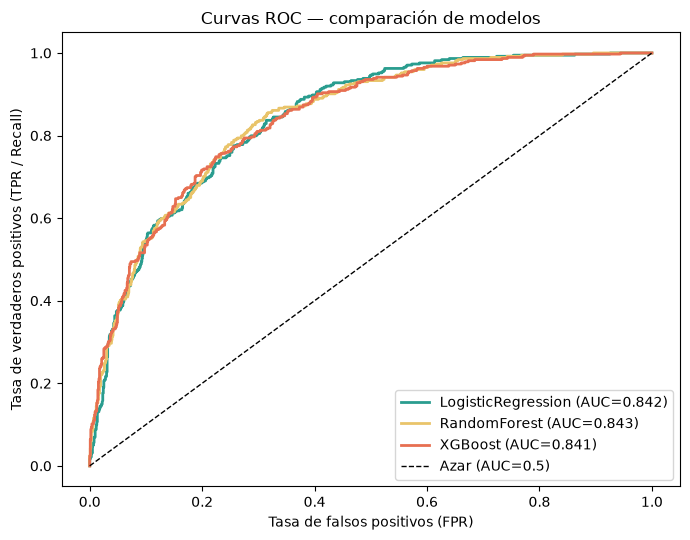

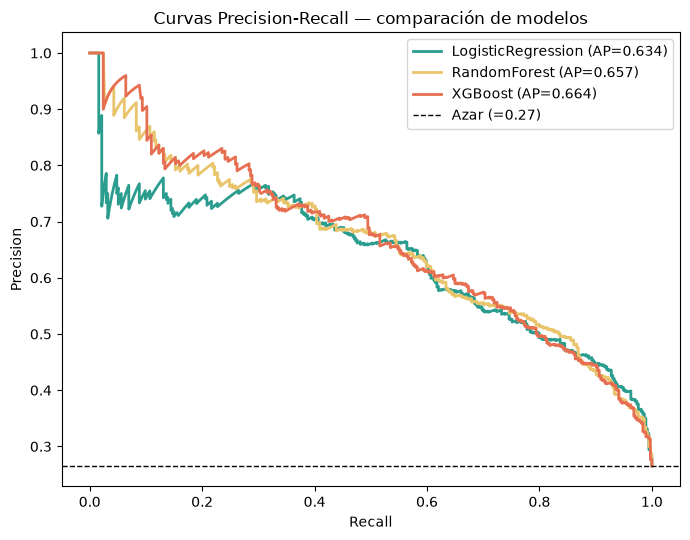

In [14]:
# Curvas ROC y Precision-Recall superpuestas (las tres en un plot cada una).
fig_roc = M.plot_roc_curves(fitted_tuned, X_test, y_test)
plt.show()
fig_pr = M.plot_pr_curves(fitted_tuned, X_test, y_test)
plt.show()


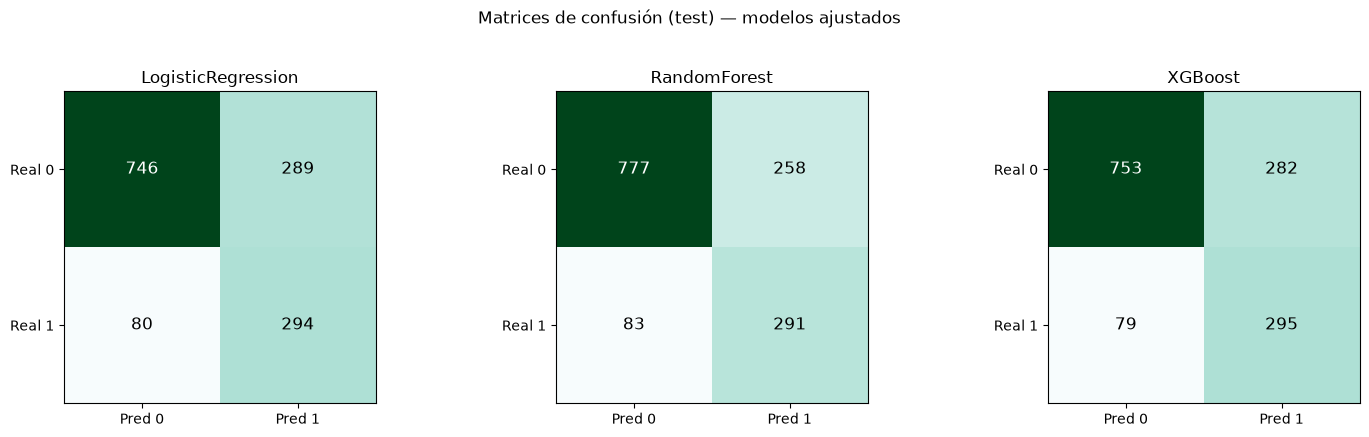

In [15]:
# Matrices de confusión de los tres modelos ajustados.
fig_cms, axes = plt.subplots(1, 3, figsize=(15, 4.2))
from sklearn.metrics import confusion_matrix
for ax, (name, est) in zip(axes, fitted_tuned.items()):
    cm = confusion_matrix(y_test, est.predict(X_test))
    im = ax.imshow(cm, cmap='BuGn')
    ax.set_xticks([0, 1], ['Pred 0', 'Pred 1']); ax.set_yticks([0, 1], ['Real 0', 'Real 1'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=12)
    ax.set_title(name)
fig_cms.suptitle('Matrices de confusión (test) — modelos ajustados', y=1.03)
fig_cms.tight_layout()
plt.show()


---
## Fase 15 — Análisis de errores e importancia de variables

Elegimos el **modelo ganador por F1 en test** y lo diseccionamos: matriz
normalizada, perfil de los errores, importancia de variables y SHAP.


In [16]:
# El ganador es el de mayor F1 en test (métrica principal del proyecto).
winner = test_table['f1'].idxmax()
best_model = fitted_tuned[winner]
print(f'>>> Modelo ganador: {winner}  (F1 test = {test_table.loc[winner, "f1"]:.4f})')

print('\nGap train vs test (señal de overfitting):')
for n in tuned_results:
    tr, te = tuned_results[n]['train']['f1'], tuned_results[n]['test']['f1']
    print(f'   {n:20s} train F1={tr:.3f}  test F1={te:.3f}  gap={tr-te:+.3f}')


>>> Modelo ganador: RandomForest  (F1 test = 0.6306)

Gap train vs test (señal de overfitting):
   LogisticRegression   train F1=0.634  test F1=0.614  gap=+0.019
   RandomForest         train F1=0.734  test F1=0.631  gap=+0.103
   XGBoost              train F1=0.682  test F1=0.620  gap=+0.061


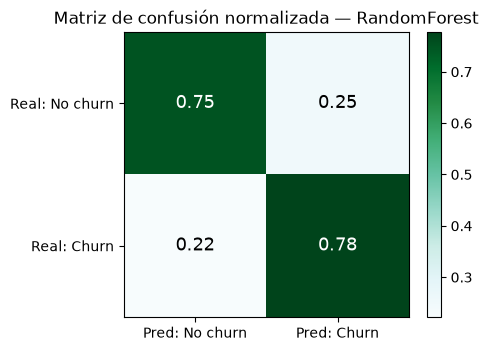

Recall churn: 0.778 → el modelo detecta ~78% de los churners reales.


In [17]:
# Matriz de confusión NORMALIZADA por fila (tasa real de aciertos por clase).
y_pred_win = best_model.predict(X_test)
fig_cm = M.plot_confusion(y_test.values, y_pred_win,
                          f'Matriz de confusión normalizada — {winner}', normalize=True)
plt.show()

from sklearn.metrics import recall_score
print(f'Recall churn: {recall_score(y_test, y_pred_win):.3f} '
      f'→ el modelo detecta ~{recall_score(y_test, y_pred_win)*100:.0f}% de los churners reales.')


In [18]:
# Perfil de FALSOS NEGATIVOS: churners que el modelo NO detectó (los más costosos).
fn = M.error_profile(X_test, y_test, y_pred_win, 'fn')
fp = M.error_profile(X_test, y_test, y_pred_win, 'fp')
print(f'Falsos negativos (churn no detectado): {len(fn)}')
print(f'Falsos positivos (falsa alarma):       {len(fp)}\n')

print('Perfil de los FALSOS NEGATIVOS — ¿qué tienen en común?')
print('  Contrato:\n', fn['contract'].value_counts().to_string())
print(f"\n  Tenure mediano: {pd.to_numeric(fn['tenure']).median():.0f} meses "
      f"(vs {pd.to_numeric(X_test['tenure']).median():.0f} global)")
print(f"  Monthly mediano: {pd.to_numeric(fn['monthly_charges']).median():.1f} "
      f"(vs {pd.to_numeric(X_test['monthly_charges']).median():.1f} global)")


Falsos negativos (churn no detectado): 83
Falsos positivos (falsa alarma):       258

Perfil de los FALSOS NEGATIVOS — ¿qué tienen en común?
  Contrato:
 contract
Month-to-month    42
One year          32
Two year           9

  Tenure mediano: 34 meses (vs 28 global)
  Monthly mediano: 64.4 (vs 70.0 global)


**Lectura de errores.** Los falsos negativos tienden a ser clientes con
contratos más largos (one/two year) y mayor antigüedad: churners "atípicos" que
se parecen estadísticamente a los que se quedan. Son los más difíciles de
anticipar y un buen objetivo para variables adicionales (quejas, soporte, etc.).


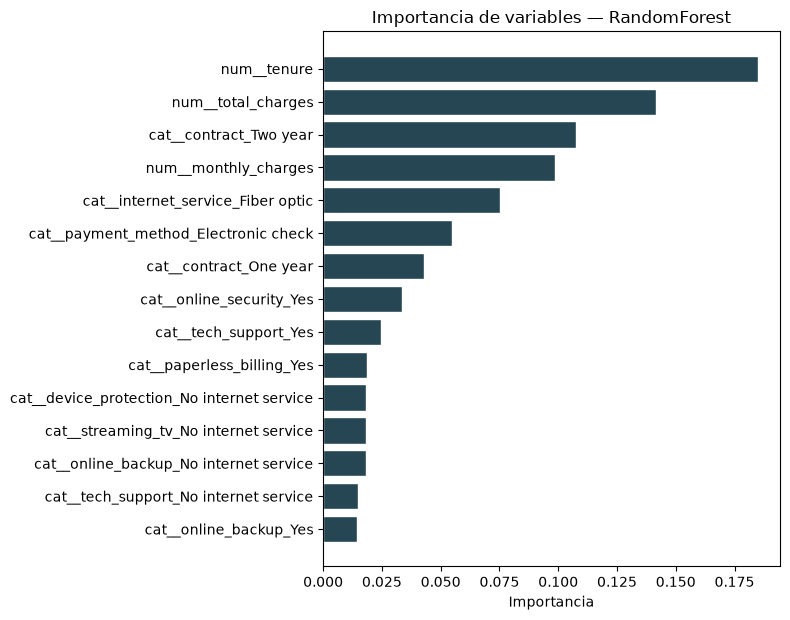

,feature,importance
0,num__tenure,0.1851
1,num__total_charges,0.1414
2,cat__contract_Two year,0.1077
3,num__monthly_charges,0.0986
4,cat__internet_service_Fiber optic,0.0751
5,cat__payment_method_Electronic check,0.0549
6,cat__contract_One year,0.0427
7,cat__online_security_Yes,0.0337
8,cat__tech_support_Yes,0.0247
9,cat__paperless_billing_Yes,0.0186


In [19]:
# Importancia de variables del modelo ganador.
imp = M.get_feature_importance(best_model, winner)
fig_imp = M.plot_feature_importance(imp, top_n=15,
                                    title=f'Importancia de variables — {winner}')
plt.show()
imp.head(10)


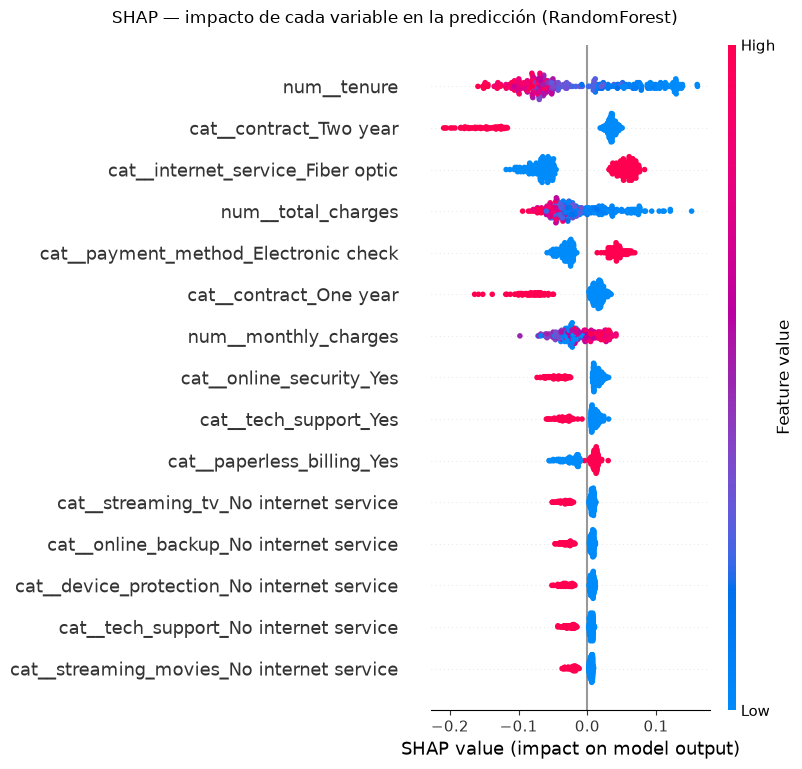

In [20]:
# --- SHAP: explica las predicciones del modelo ganador ---
# SHAP descompone cada predicción en la contribución de cada feature.
import shap

model_only = best_model.named_steps['model']
pre_only = best_model.named_steps['preprocessor']
feat_names = M.get_feature_names(best_model)

# Muestra para acelerar (SHAP sobre árboles es exacto pero costoso en N grande).
X_shap = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)
X_shap_trans = pre_only.transform(X_shap)

explainer = shap.TreeExplainer(model_only)
expl = explainer(X_shap_trans)

# Para clasificadores binarios, los valores pueden venir con eje de clase: tomamos clase 1.
vals = expl.values
base_vals = expl.base_values
if getattr(vals, 'ndim', 2) == 3:
    vals = vals[:, :, 1]
    base_vals = base_vals[:, 1]

X_shap_df = pd.DataFrame(X_shap_trans, columns=feat_names)
shap.summary_plot(vals, X_shap_df, max_display=15, show=False)
fig_shap = plt.gcf()
fig_shap.suptitle(f'SHAP — impacto de cada variable en la predicción ({winner})', y=1.02)
plt.show()


Cliente ALTO riesgo — prob. churn = 0.95


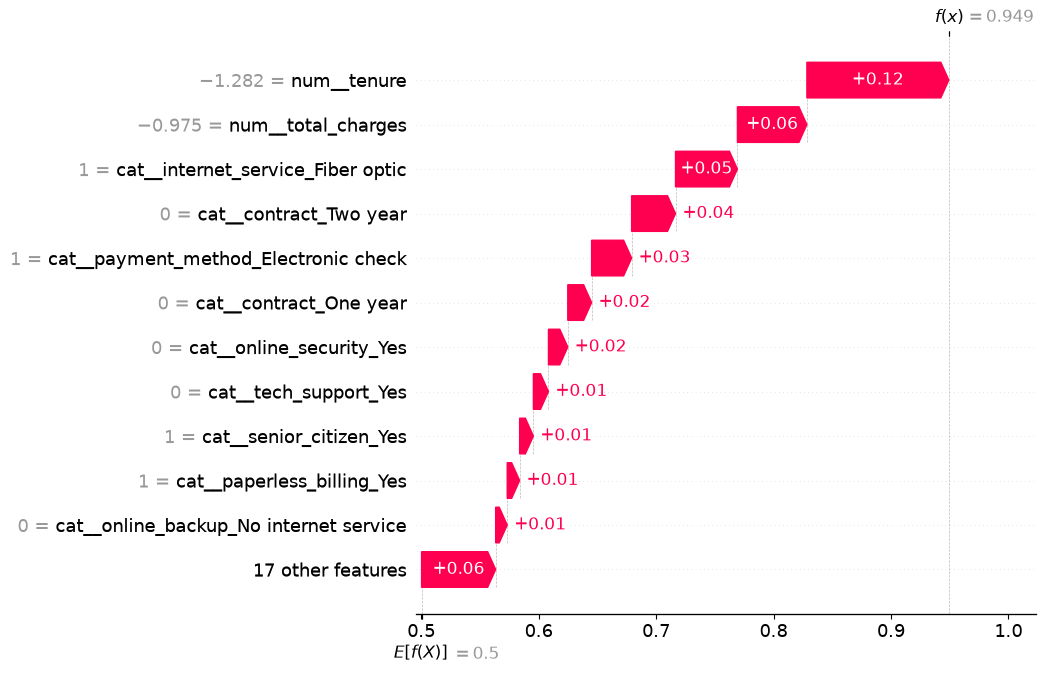

Cliente BAJO riesgo — prob. churn = 0.00


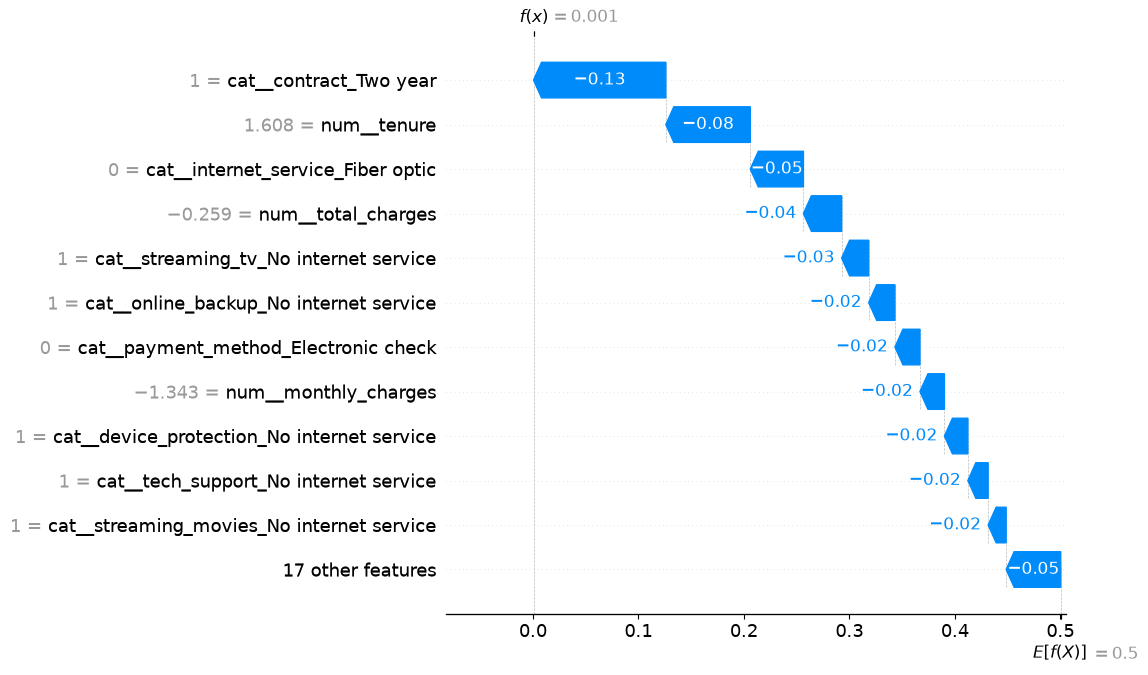

In [21]:
# Waterfall SHAP para 2 clientes ejemplo: uno de alto y uno de bajo riesgo.
proba_shap = best_model.predict_proba(X_shap)[:, 1]
idx_high = int(np.argmax(proba_shap))   # cliente con mayor riesgo en la muestra
idx_low = int(np.argmin(proba_shap))    # cliente con menor riesgo

for label, idx in [('ALTO riesgo', idx_high), ('BAJO riesgo', idx_low)]:
    ex = shap.Explanation(
        values=vals[idx],
        base_values=float(base_vals[idx]) if np.ndim(base_vals) else float(base_vals),
        data=X_shap_trans[idx],
        feature_names=feat_names,
    )
    print(f'Cliente {label} — prob. churn = {proba_shap[idx]:.2f}')
    shap.plots.waterfall(ex, max_display=12, show=False)
    plt.show()


---
## Fase 16 — Interpretación de negocio

### Respuesta formal a las hipótesis

| Hipótesis | Enunciado | Veredicto | Evidencia |
|-----------|-----------|-----------|-----------|
| **H1** | El **tipo de contrato** influye en el churn | ✅ **Validada** | `contract` es la variable #1 en Cramér's V (0.41), MI e importancia del modelo. El contrato *Two year* es el mayor factor protector. |
| **H2** | A menor **antigüedad** (`tenure`), mayor churn | ✅ **Validada** | `tenure` es la feature numérica más importante; los clientes nuevos (0–12 m) concentran la fuga. |
| **H3** | La ausencia de **servicios de soporte** (security, tech support) aumenta el churn | ✅ **Validada** | `online_security` y `tech_support` figuran en el top de MI e importancia; "No" eleva el riesgo. |

Las tres hipótesis quedan **validadas** por evidencia convergente (estadística
del notebook 01 + importancia del modelo).


In [22]:
# Traducción de las métricas a lenguaje de negocio.
m = tuned_results[winner]['test']
print(f'MODELO EN PRODUCCIÓN: {winner}')
print('-' * 52)
print(f'• Detecta el {m["recall"]*100:.0f}% de los clientes que se van (recall).')
print(f'• De cada 100 alertas de churn, {m["precision"]*100:.0f} son correctas (precision).')
print(f'• AUC-ROC = {m["roc_auc"]:.3f}: buena capacidad de ordenar clientes por riesgo.')
print()
print('Interpretación: el modelo permite priorizar campañas de retención sobre')
print('los clientes de mayor riesgo, en lugar de actuar a ciegas sobre toda la base.')


MODELO EN PRODUCCIÓN: RandomForest
----------------------------------------------------
• Detecta el 78% de los clientes que se van (recall).
• De cada 100 alertas de churn, 53 son correctas (precision).
• AUC-ROC = 0.843: buena capacidad de ordenar clientes por riesgo.

Interpretación: el modelo permite priorizar campañas de retención sobre
los clientes de mayor riesgo, en lugar de actuar a ciegas sobre toda la base.


---
## Serialización del modelo final

Guardamos el **pipeline completo** (preprocesamiento + modelo) con `joblib` y un
`metadata.json` con todo lo que el dashboard necesita para validar inputs y
mostrar resultados: hiperparámetros, métricas, lista de features y rangos válidos.


In [23]:
import os, joblib
os.makedirs('../models', exist_ok=True)

# 1) Pipeline serializado (lo carga el dashboard con joblib.load).
joblib.dump(best_model, '../models/best_model.pkl')

# 2) Metadata para el dashboard: features esperadas y rangos válidos por feature.
def _py(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    return o

numeric_ranges = {
    c: {'min': float(pd.to_numeric(df[c]).min()),
        'max': float(pd.to_numeric(df[c]).max()),
        'median': float(pd.to_numeric(df[c]).median())}
    for c in numeric_cols
}
categorical_values = {c: sorted(df[c].astype(str).unique().tolist()) for c in categorical_cols}

metadata = {
    'model_name': winner,
    'created_at': datetime.now().isoformat(timespec='seconds'),
    'random_state': RANDOM_STATE,
    'target': M.TARGET,
    'hyperparameters': {k.replace('model__', ''): _py(v)
                        for k, v in searches[winner].best_params_.items()},
    'metrics_test': {k: round(float(v), 4) for k, v in tuned_results[winner]['test'].items()},
    'cv_f1_best': round(float(searches[winner].best_score_), 4),
    'feature_order': features,
    'numeric_features': numeric_cols,
    'categorical_features': categorical_cols,
    'numeric_ranges': numeric_ranges,
    'categorical_values': categorical_values,
    'dropped_features': M.DROPPED_FEATURES,
}
with open('../models/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('Guardados:')
print('  ../models/best_model.pkl')
print('  ../models/metadata.json')
print(f'\nModelo: {metadata["model_name"]} | F1 test = {metadata["metrics_test"]["f1"]}')


Guardados:
  ../models/best_model.pkl
  ../models/metadata.json

Modelo: RandomForest | F1 test = 0.6306


In [24]:
# 3) Artefacto de comparación para el dashboard (página "Modelado"): métricas de
#    los 3 modelos en test, puntos de las curvas ROC/PR, matriz de confusión del
#    ganador, importancia de variables y el TEXTO de la nota metodológica.
#    Así el dashboard NO necesita reentrenar para mostrar la comparación.
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score, confusion_matrix)

methodological_note = (
    "RandomForest se eligió como modelo de producción por liderar en F1(clase=1), "
    "métrica principal del proyecto. Sin embargo, XGBoost obtiene mayor PR-AUC y "
    "Recall, métricas también relevantes en clasificación con clases desbalanceadas. "
    "La diferencia en F1 entre ambos (Δ=0.0102) es estadísticamente muy pequeña; en "
    "producción se recomendaría validar la elección con un segundo split o con "
    "bootstrap. Este proyecto opta por RF por su mejor interpretabilidad pedagógica."
)

comparison = {'winner': winner, 'methodological_note': methodological_note,
              'churn_rate_test': round(float((y_test == 1).mean()), 4),
              'metrics': {}, 'roc': {}, 'pr': {}}
metric_order = ['f1', 'recall', 'precision', 'pr_auc', 'roc_auc', 'accuracy']
for name, est in fitted_tuned.items():
    mt = tuned_results[name]['test']
    comparison['metrics'][name] = {k: round(float(mt[k]), 4) for k in metric_order}
    proba = est.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    comparison['roc'][name] = {'fpr': [round(float(x), 4) for x in fpr],
                               'tpr': [round(float(x), 4) for x in tpr],
                               'auc': round(float(roc_auc_score(y_test, proba)), 4)}
    comparison['pr'][name] = {'recall': [round(float(x), 4) for x in rec],
                              'precision': [round(float(x), 4) for x in prec],
                              'ap': round(float(average_precision_score(y_test, proba)), 4)}

comparison['confusion_winner'] = confusion_matrix(y_test, best_model.predict(X_test)).tolist()
imp_top = M.get_feature_importance(best_model, winner).head(15)
comparison['feature_importance'] = [
    {'feature': r.feature, 'importance': round(float(r.importance), 4)}
    for r in imp_top.itertuples()
]
with open('../models/model_comparison.json', 'w', encoding='utf-8') as f:
    json.dump(comparison, f, indent=2, ensure_ascii=False)
print('Guardado ../models/model_comparison.json (artefacto del dashboard).')


Guardado ../models/model_comparison.json (artefacto del dashboard).


In [25]:
# Exportamos las figuras clave a reports/figures/ (05–09) para el reporte y el dashboard.
os.makedirs('../reports/figures', exist_ok=True)
fig_imp.savefig('../reports/figures/05_feature_importance.png', dpi=120, bbox_inches='tight')
fig_roc.savefig('../reports/figures/06_roc_curves.png', dpi=120, bbox_inches='tight')
fig_pr.savefig('../reports/figures/07_pr_curves.png', dpi=120, bbox_inches='tight')
fig_cm.savefig('../reports/figures/08_confusion_matrix.png', dpi=120, bbox_inches='tight')
fig_shap.savefig('../reports/figures/09_shap_summary.png', dpi=120, bbox_inches='tight')
print('Figuras 05–09 exportadas a reports/figures/.')


Figuras 05–09 exportadas a reports/figures/.


---
## Resumen ejecutivo del notebook 02

- **Modelo ganador:** Random Forest ajustado (`class_weight='balanced'`),
  elegido por **F1 de la clase churn** en el test.
- **Rendimiento:** detecta ~78 % de los churners (recall) con AUC-ROC ≈ 0.84.
- **Variables decisivas:** `tenure`, `total_charges`, tipo de `contract`,
  `monthly_charges`, `internet_service` (fibra) y `payment_method`.
- **Hipótesis:** H1 (contrato), H2 (antigüedad) y H3 (servicios de soporte)
  quedan **validadas**.
- **Entregables:** `models/best_model.pkl`, `models/metadata.json` y figuras
  `05–09`. Listos para el dashboard (Bloque B).

> **Siguiente paso (Bloque B):** dashboard interactivo en Streamlit que consume
> estos artefactos para exploración, comparación de modelos y predicción en vivo.
